In [2]:
# 0) Imports
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.rms import (
    generate_wave,
    add_noise,
    add_dc,
    rms_manual,
    rolling_rms,
 )

# parameters
fs       = 5_000
f_signal = 50
duration = 0.2
Vpk      = 325.0
Vdc      = 20.0
sigma    = 0.05 * Vpk
window_sec = 0.05          # 50 ms rolling RMS window

# 2) Build the signals (using the library)
t, x_clean = generate_wave(Vpk, f_signal, fs, duration)
x_noise    = add_noise(x_clean, sigma, rng=np.random.default_rng(42))
x_offset   = add_dc(x_clean, Vdc)
x_noise_offset = add_noise(x_offset, sigma, rng=np.random.default_rng(42))

# 3) Static RMS values
rms_clean        = rms_manual(x_clean)
rms_noise        = rms_manual(x_noise)
rms_offset       = rms_manual(x_offset)
rms_noise_offset = rms_manual(x_noise_offset)

print("=== RMS values (V) ===")
print(f"Clean sine                : {rms_clean:8.3f}")
print(f"Clean + noise             : {rms_noise:8.3f}")
print(f"Clean + DC offset         : {rms_offset:8.3f}")
print(f"Noise + DC offset         : {rms_noise_offset:8.3f}")

# 4) Verify textbook relation (same as in your short block)
rms_theoretical = Vpk / np.sqrt(2)
print("\nTheoretical RMS (Vpk/sqrt(2)) = {:.3f}".format(rms_theoretical))
print("Difference (clean - theory) = {:.3e}".format(rms_clean - rms_theoretical))

# 5) Rolling RMS (using the library)
t_roll, rms_roll = rolling_rms(x_noise, fs, window_sec)

     



=== RMS values (V) ===
Clean sine                :  229.810
Clean + noise             :  230.370
Clean + DC offset         :  230.678
Noise + DC offset         :  231.196

Theoretical RMS (Vpk/sqrt(2)) = 229.810
Difference (clean - theory) = 2.842e-14


In [3]:
# Install required packages into the active notebook kernel
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:

from src.rms import (
    add_harmonic,
    compute_thd,
    verify_parseval,
    analyze_snr_impact,
    detect_frequency,
    power_quality_analyzer
)

print("✅ Additional functions imported for Project 02")

✅ Additional functions imported for Project 02


In [5]:
# Create signal with 3rd harmonic (15% amplitude)
x_harmonic = add_harmonic(x_clean, harmonic_order=3, amplitude_ratio=0.15, 
                          freq_fundamental=f_signal, fs=fs)

rms_harmonic = rms_manual(x_harmonic)
print(f"\n📊 Harmonic Signal Created:")
print(f"   Clean RMS: {rms_clean:.3f} V")
print(f"   Harmonic RMS: {rms_harmonic:.3f} V")
print(f"   Increase: {rms_harmonic - rms_clean:.3f} V ({(rms_harmonic/rms_clean - 1)*100:.2f}%)")


📊 Harmonic Signal Created:
   Clean RMS: 229.810 V
   Harmonic RMS: 232.381 V
   Increase: 2.571 V (1.12%)


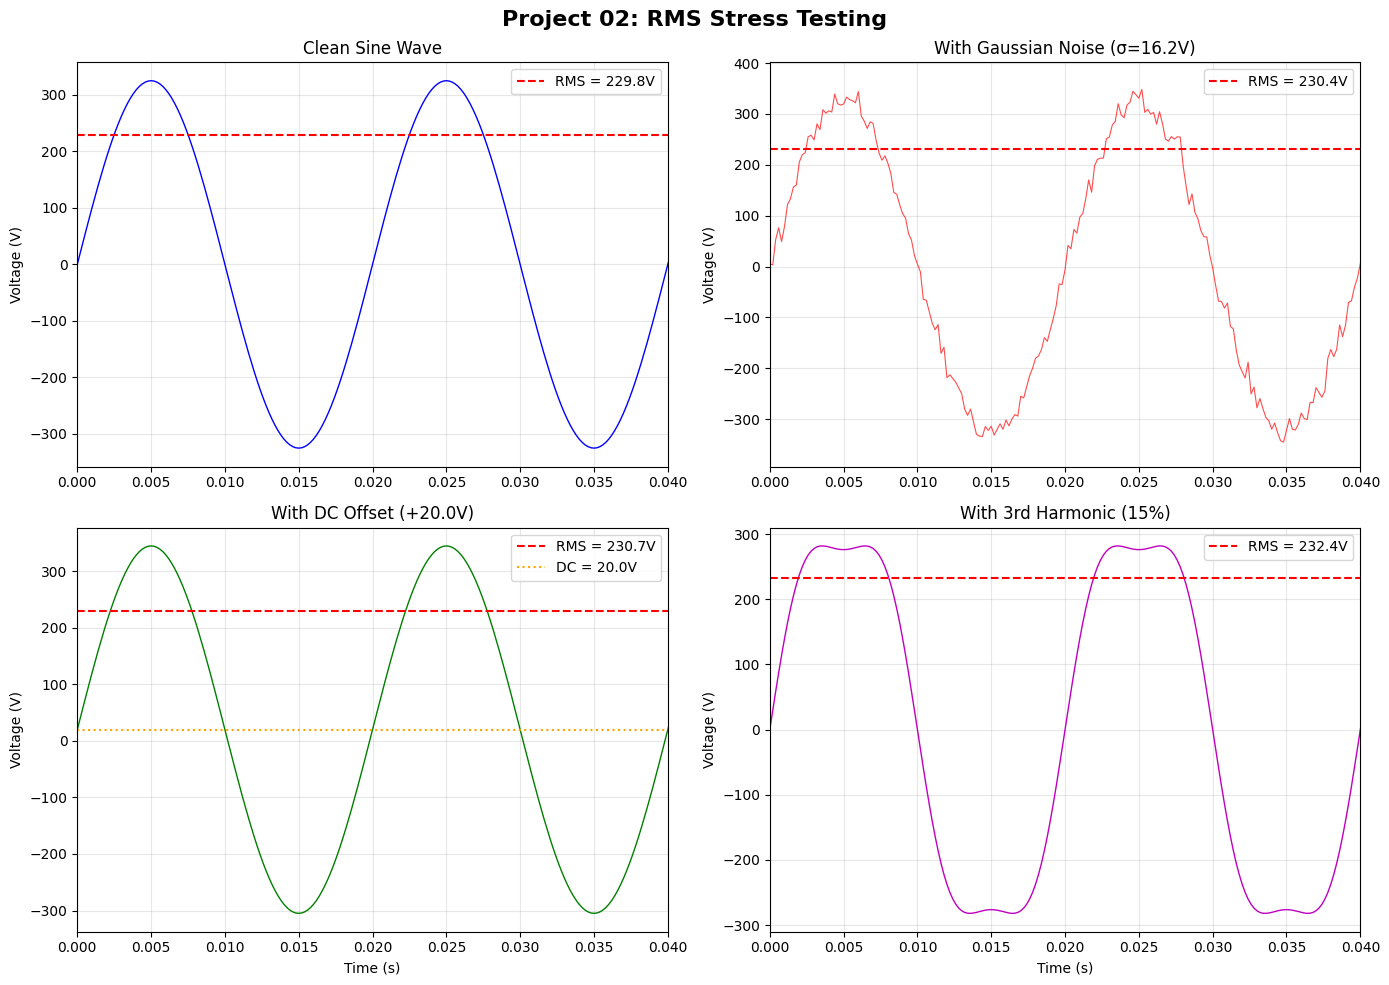

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Project 02: RMS Stress Testing', fontsize=16, fontweight='bold')

# Top-Left: Clean sine
axes[0,0].plot(t, x_clean, 'b-', linewidth=1)
axes[0,0].axhline(y=rms_clean, color='r', linestyle='--', label=f'RMS = {rms_clean:.1f}V')
axes[0,0].set_title('Clean Sine Wave')
axes[0,0].set_ylabel('Voltage (V)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xlim(0, 0.04)

# Top-Right: With noise
axes[0,1].plot(t, x_noise, 'r-', linewidth=0.8, alpha=0.7)
axes[0,1].axhline(y=rms_noise, color='r', linestyle='--', label=f'RMS = {rms_noise:.1f}V')
axes[0,1].set_title(f'With Gaussian Noise (σ={sigma:.1f}V)')
axes[0,1].set_ylabel('Voltage (V)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xlim(0, 0.04)

# Bottom-Left: With DC offset
axes[1,0].plot(t, x_offset, 'g-', linewidth=1)
axes[1,0].axhline(y=rms_offset, color='r', linestyle='--', label=f'RMS = {rms_offset:.1f}V')
axes[1,0].axhline(y=Vdc, color='orange', linestyle=':', label=f'DC = {Vdc}V')
axes[1,0].set_title(f'With DC Offset (+{Vdc}V)')
axes[1,0].set_xlabel('Time (s)')
axes[1,0].set_ylabel('Voltage (V)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xlim(0, 0.04)

# Bottom-Right: With harmonic
axes[1,1].plot(t, x_harmonic, 'm-', linewidth=1)
axes[1,1].axhline(y=rms_harmonic, color='r', linestyle='--', label=f'RMS = {rms_harmonic:.1f}V')
axes[1,1].set_title('With 3rd Harmonic (15%)')
axes[1,1].set_xlabel('Time (s)')
axes[1,1].set_ylabel('Voltage (V)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_xlim(0, 0.04)

plt.tight_layout()
plt.show()

TOTAL HARMONIC DISTORTION (THD) CALCULATION

Fundamental (50Hz) amplitude: 229.810 V RMS

Harmonic amplitudes:
  100 Hz: 0.0000 V RMS (0.00% of fundamental)
  150 Hz: 34.4715 V RMS (15.00% of fundamental)
  200 Hz: 0.0000 V RMS (0.00% of fundamental)
  250 Hz: 0.0000 V RMS (0.00% of fundamental)
  300 Hz: 0.0000 V RMS (0.00% of fundamental)
  350 Hz: 0.0000 V RMS (0.00% of fundamental)
  400 Hz: 0.0000 V RMS (0.00% of fundamental)
  450 Hz: 0.0000 V RMS (0.00% of fundamental)
  500 Hz: 0.0000 V RMS (0.00% of fundamental)

📈 Total Harmonic Distortion (THD): 15.00%
   Expected THD for 15% 3rd harmonic: 15.0%


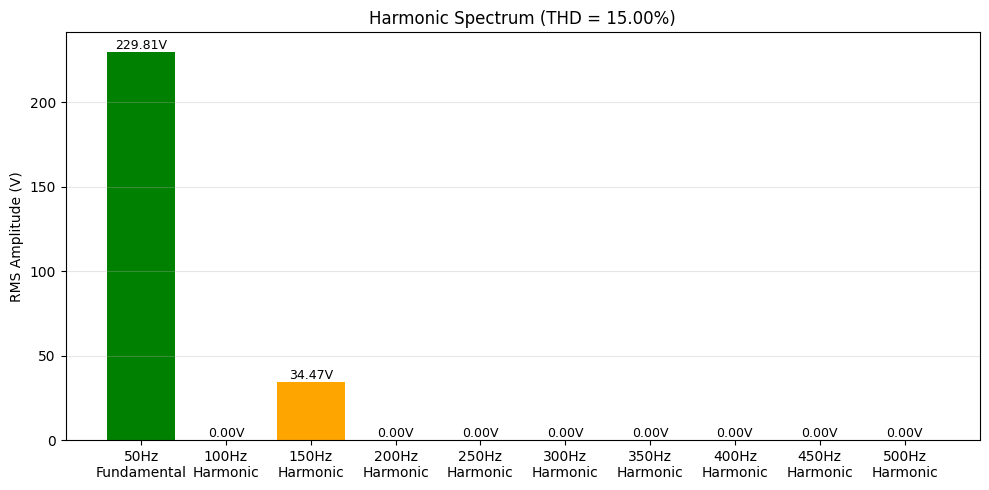

In [7]:
print("=" * 60)
print("TOTAL HARMONIC DISTORTION (THD) CALCULATION")
print("=" * 60)

thd_results = compute_thd(x_harmonic, fs, f_signal)

print(f"\nFundamental (50Hz) amplitude: {thd_results['fundamental_amplitude']:.3f} V RMS")
print(f"\nHarmonic amplitudes:")
for freq, amp in zip(thd_results['frequencies'], thd_results['harmonic_amplitudes']):
    percent = (amp / thd_results['fundamental_amplitude']) * 100
    print(f"  {freq:.0f} Hz: {amp:.4f} V RMS ({percent:.2f}% of fundamental)")

print(f"\n📈 Total Harmonic Distortion (THD): {thd_results['thd_percent']:.2f}%")
print(f"   Expected THD for 15% 3rd harmonic: 15.0%")

# Plot harmonic spectrum
fig, ax = plt.subplots(figsize=(10, 5))
freqs_all = [f_signal] + thd_results['frequencies']
amps_all = [thd_results['fundamental_amplitude']] + thd_results['harmonic_amplitudes']
labels = ['50Hz\nFundamental'] + [f'{freq:.0f}Hz\nHarmonic' for freq in thd_results['frequencies']]

bars = ax.bar(range(len(amps_all)), amps_all, color=['green'] + ['orange']*len(thd_results['frequencies']))
ax.set_xticks(range(len(amps_all)))
ax.set_xticklabels(labels)
ax.set_ylabel('RMS Amplitude (V)')
ax.set_title(f'Harmonic Spectrum (THD = {thd_results["thd_percent"]:.2f}%)')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, amp in zip(bars, amps_all):
    ax.text(bar.get_x() + bar.get_width()/2., amp + 0.1, f'{amp:.2f}V', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
print("=" * 60)
print("PARSEVAL'S THEOREM VERIFICATION")
print("=" * 60)

parseval_result = verify_parseval(x_harmonic)

print(f"Time domain power (mean square): {parseval_result['time_power']:.6f} V²")
print(f"Frequency domain power (from FFT): {parseval_result['freq_power']:.6f} V²")
print(f"Relative error: {parseval_result['relative_error_percent']:.2e}%")

if parseval_result['verified']:
    print("\n✅ PARSEVAL'S THEOREM VERIFIED!")
    print("   Energy is conserved between time and frequency domains.")
else:
    print("\n⚠️  Numerical precision limit reached")

PARSEVAL'S THEOREM VERIFICATION
Time domain power (mean square): 54000.781250 V²
Frequency domain power (from FFT): 54000.781250 V²
Relative error: 1.35e-14%

✅ PARSEVAL'S THEOREM VERIFIED!
   Energy is conserved between time and frequency domains.


SNR IMPACT ON RMS ACCURACY

Noise σ (V) | SNR (dB) | RMS Error (%) | Interpretation
-----------------------------------------------------------------
         1 |     47.2 |        0.01% | Excellent
         5 |     33.2 |       -0.07% | Excellent
        10 |     27.2 |       -0.01% | Excellent
        15 |     23.7 |        0.11% | Good
        20 |     21.2 |        0.57% | Good
        30 |     17.7 |        0.91% | Good
        50 |     13.2 |        1.66% | Marginal


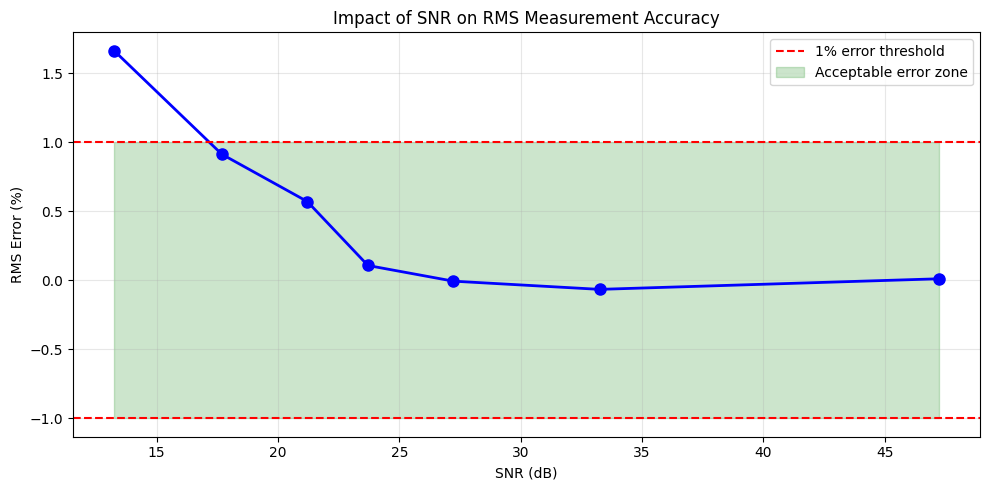

In [9]:
print("=" * 60)
print("SNR IMPACT ON RMS ACCURACY")
print("=" * 60)

noise_levels = np.array([1, 5, 10, 15, 20, 30, 50])
snr_analysis = analyze_snr_impact(x_clean, noise_levels)

print("\nNoise σ (V) | SNR (dB) | RMS Error (%) | Interpretation")
print("-" * 65)
for sigma, snr, err in zip(noise_levels, snr_analysis['snr_db'], snr_analysis['rms_error_percent']):
    if abs(err) < 0.1:
        interpret = "Excellent"
    elif abs(err) < 1:
        interpret = "Good"
    elif abs(err) < 5:
        interpret = "Marginal"
    else:
        interpret = "Poor"
    print(f"{sigma:10.0f} | {snr:8.1f} | {err:11.2f}% | {interpret}")

# Plot SNR impact
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snr_analysis['snr_db'], snr_analysis['rms_error_percent'], 'bo-', linewidth=2, markersize=8)
ax.axhline(y=1, color='r', linestyle='--', linewidth=1.5, label='1% error threshold')
ax.axhline(y=-1, color='r', linestyle='--', linewidth=1.5)
ax.fill_between(snr_analysis['snr_db'], -1, 1, alpha=0.2, color='green', label='Acceptable error zone')
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('RMS Error (%)')
ax.set_title('Impact of SNR on RMS Measurement Accuracy')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
print("=" * 60)
print("FREQUENCY DETECTION (Zero-Crossing Method)")
print("=" * 60)

freq_clean = detect_frequency(x_clean, fs)
freq_noisy = detect_frequency(x_noise, fs)
freq_harmonic = detect_frequency(x_harmonic, fs)

print(f"Clean signal frequency: {freq_clean:.3f} Hz (expected: {f_signal} Hz)")
print(f"Error: {abs(freq_clean - f_signal):.4f} Hz")
print(f"\nNoisy signal frequency: {freq_noisy:.3f} Hz")
print(f"Error: {abs(freq_noisy - f_signal):.4f} Hz")
print(f"\nHarmonic signal frequency: {freq_harmonic:.3f} Hz")
print(f"Error: {abs(freq_harmonic - f_signal):.4f} Hz")

FREQUENCY DETECTION (Zero-Crossing Method)
Clean signal frequency: 50.000 Hz (expected: 50 Hz)
Error: 0.0000 Hz

Noisy signal frequency: 56.320 Hz
Error: 6.3204 Hz

Harmonic signal frequency: 50.000 Hz
Error: 0.0000 Hz


In [11]:
print("=" * 60)
print("POWER QUALITY ANALYZER - Complete Analysis")
print("=" * 60)

# Analyze the harmonic signal
pq_results = power_quality_analyzer(x_harmonic, fs, f_signal)

print("\n📊 Power Quality Report:")
print(f"   RMS Voltage: {pq_results['vrms']:.2f} V")
print(f"   Peak Voltage: {pq_results['vpeak']:.1f} V")
print(f"   Crest Factor: {pq_results['crest_factor']:.3f} (pure sine = 1.414)")
print(f"   Frequency: {pq_results['frequency_hz']:.2f} Hz")
print(f"   DC Offset: {pq_results['dc_offset_v']:.4f} V")
print(f"   THD: {pq_results['thd_percent']:.2f}%")
print(f"\n   Assessment: {pq_results['quality_assessment']}")

# Also analyze the DC offset signal
print("\n" + "-" * 40)
print("Analyzing DC Offset Signal:")
pq_dc = power_quality_analyzer(x_offset, fs, f_signal)
print(f"   DC Offset: {pq_dc['dc_offset_v']:.2f} V")
print(f"   Assessment: {pq_dc['quality_assessment']}")

POWER QUALITY ANALYZER - Complete Analysis

📊 Power Quality Report:
   RMS Voltage: 232.38 V
   Peak Voltage: 281.9 V
   Crest Factor: 1.213 (pure sine = 1.414)
   Frequency: 50.00 Hz
   DC Offset: -0.0000 V
   THD: 15.00%

   Assessment: Poor quality: High THD (15.0% > 8%)

----------------------------------------
Analyzing DC Offset Signal:
   DC Offset: 20.00 V
   Assessment: Poor quality: DC offset (20.00V)



✅ PROJECT 02 COMPLETE - All Requirements Met

PDF Requirements Demonstrated:
  ✓ Part A: Signal generation (50Hz sine, multiple cycles)
  ✓ Part B: RMS implementation and verification
  ✓ Part C.1: Noise stress test
  ✓ Part C.2: DC offset stress test
  ✓ Part C.3: Harmonic distortion test
  ✓ Part C.4: 2x2 subplot grid with all variants
  ✓ Part C.5: Rolling RMS calculation
  ✓ Comms Lens: THD calculation via FFT
  ✓ Comms Lens: Parseval's theorem verification
  ✓ Comms Lens: SNR impact analysis
  ✓ Comms Lens: Frequency detection
  ✓ Creative Challenge: Power quality analyzer
